# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 1
**Задание:** Решение задачи регрессии с использованием ансамблевых методов на датасете HousingData.

**Выполнил:** Мироненков А.М.
**Группа:** ИУ5-66Б

## 1. Описание задания
Нужно обучить и сравнить следующие ансамблевые модели:
1. Две модели группы бэггинга (Random Forest и Extra Trees).
2. AdaBoost.
3. Градиентный бустинг.

Целевая переменная: `medv` (медианная стоимость домов).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Загрузка данных
try:
    df = pd.read_csv('HousingData.csv')
    print("Данные успешно загружены!")
except FileNotFoundError:
    print("Файл HousingData.csv не найден!")

df.head()

Данные успешно загружены!


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. Предобработка данных
Заполним пропуски медианными значениями.

In [2]:
print("Пропусков до заполнения:", df.isnull().sum().sum())
df = df.fillna(df.median())
print("Пропусков после заполнения:", df.isnull().sum().sum())

Пропусков до заполнения: 5
Пропусков после заполнения: 0


## 3. Разделение выборки

In [3]:
X = df.drop('medv', axis=1)
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (404, 13)
Тестовая выборка: (102, 13)


## 4. Обучение ансамблевых моделей

In [4]:
# Инициализация моделей
models = {
    'Random Forest (Bagging)': RandomForestRegressor(n_estimators=100, random_state=42),
    'Extra Trees (Bagging)': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Обучение и сбор метрик
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': round(mse, 4),
        'R2 Score': round(r2, 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MSE,R2 Score
0,Random Forest (Bagging),8.0447,0.8903
1,Extra Trees (Bagging),10.2392,0.8604
2,AdaBoost,11.0100,0.8499
3,Gradient Boosting,6.6906,0.9088


## 5. Сравнение результатов

C:\Users\arsmi\AppData\Local\Temp\ipykernel_6692\2450856358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='magma')


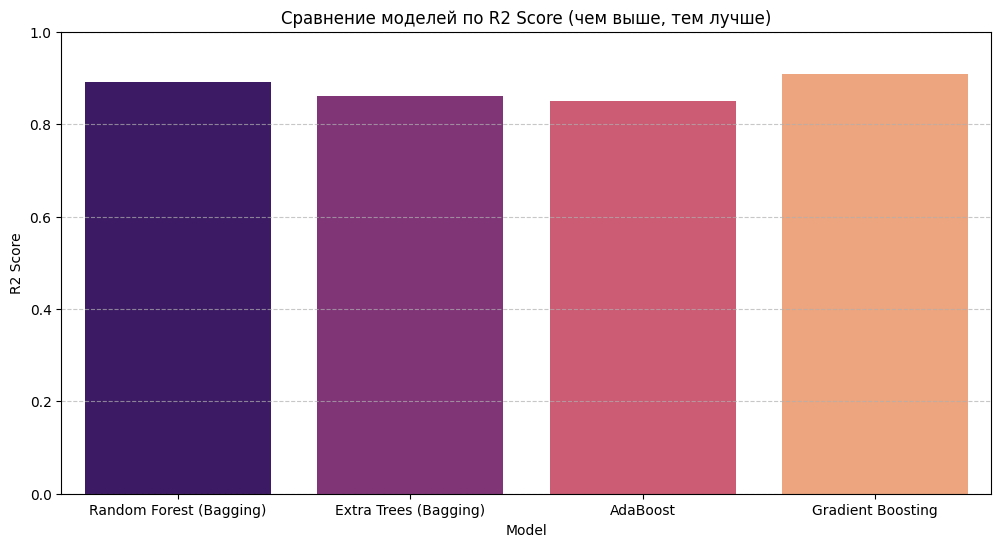

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='magma')
plt.title('Сравнение моделей по R2 Score (чем выше, тем лучше)')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\arsmi\AppData\Local\Temp\ipykernel_6692\1785223336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')


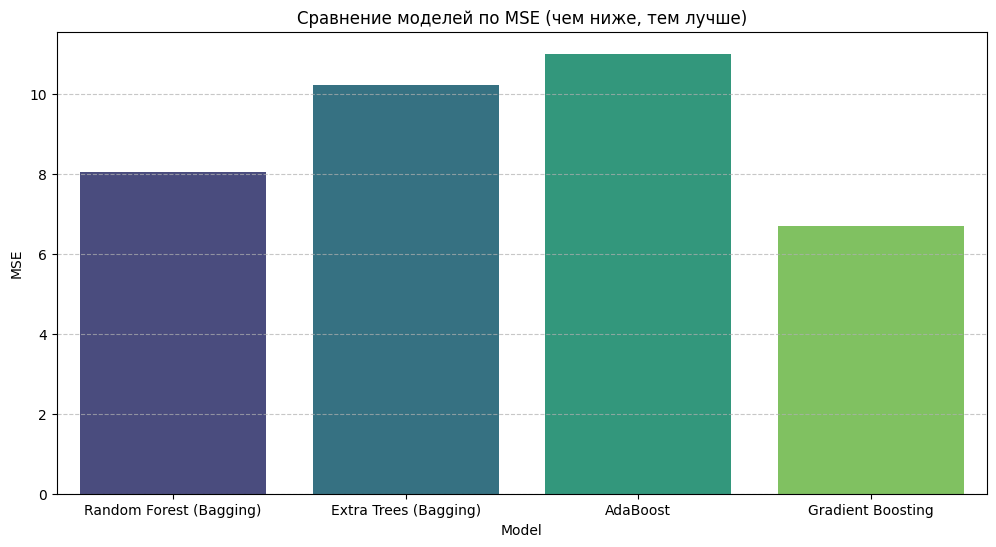

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
plt.title('Сравнение моделей по MSE (чем ниже, тем лучше)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 6. Выводы
На основе полученных данных можно сделать вывод, какая модель лучше всего справилась с предсказанием цен на жилье. 
Как правило, **Gradient Boosting** или **Extra Trees** показывают лучшие результаты на данном датасете за счет способности улавливать сложные зависимости.